In [112]:
# !pip install aiomoex
# !pip install tinkoff-investments
# !pip install yfinance

Открытые вопросы:
* Стоит ли описывать варианты получения данных и причину выбора?

Что нужно сделать ближайшее:
* Выгрузить IMOEX индекс на периоде для сравнения (в идеале потом можно еще с открытием вкладов сравнить, но сложно кодом считать)
* Реализовать функции расчета индикаторов, которые необходимы будут для обучения


In [173]:
from tinkoff.invest import Client, AsyncClient, CandleInterval, SecurityTradingStatus
from tinkoff.invest.services import InstrumentsService
from tinkoff.invest.utils import quotation_to_decimal, now
from tinkoff.invest.caching.instruments_cache.instruments_cache import InstrumentsCache

import pandas as pd
from dotenv import load_dotenv

import os
# import asyncio
import math
import time
from datetime import datetime, timezone, timedelta
from pathlib import Path
from typing import Optional
import warnings

warnings.filterwarnings("ignore")

In [114]:
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

In [115]:
load_dotenv()

# TOKEN = "REDACTED"
TOKEN = os.getenv("TOKEN")

In [116]:
tickers_to_test = ["SBER", "GLDRUB_TOM", "CNYRUB_TOM", "BRH6", "MOEX"]

Словарь настроек интервалов: (Константа API, Максимальный шаг скачивания)

In [117]:
INTERVALS = {
    "5min":  (CandleInterval.CANDLE_INTERVAL_5_MIN, timedelta(days=7)),
    "15min": (CandleInterval.CANDLE_INTERVAL_15_MIN, timedelta(days=21)),
    "1hour": (CandleInterval.CANDLE_INTERVAL_HOUR, timedelta(days=31)),
    "4hour": (CandleInterval.CANDLE_INTERVAL_4_HOUR, timedelta(days=31 * 2)),
    "1day":  (CandleInterval.CANDLE_INTERVAL_DAY, timedelta(days=365))
}

In [142]:
market_context = {
    'Year': [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025],
    'Inflation': [0.1291, 0.0538, 0.0252, 0.0427, 0.0305, 0.0491, 0.0839, 0.1192, 0.0742, 0.0951, 0.0599],
    'BankRate':  [0.15325, 0.0999, 0.084, 0.07245, 0.07529, 0.05927, 0.04486, 0.07738, 0.0813, 0.14793, 0.21723]
}
df_market = pd.DataFrame(market_context).set_index('Year')

Подробная информация по тикеру.

**Не работает с индексами вроде индекса МосБиржи**

In [119]:
def get_info(ticker, TOKEN = TOKEN):
    with Client(TOKEN) as client:
        instruments: InstrumentsService = client.instruments
        tickers = []
        for method in ["shares", "bonds", "etfs", "currencies", "futures"]:
            for item in getattr(instruments, method)().instruments:
                tickers.append(
                    {
                        "name": item.name,
                        "ticker": item.ticker,
                        "class_code": item.class_code,
                        "figi": item.figi,
                        "uid": item.uid,
                        "type": method,
                        "min_price_increment": quotation_to_decimal(
                            item.min_price_increment
                        ),
                        "scale": 9 - len(str(item.min_price_increment.nano)) + 1,
                        "lot": item.lot,
                        "trading_status": str(
                            SecurityTradingStatus(item.trading_status).name
                        ),
                        "api_trade_available_flag": item.api_trade_available_flag,
                        "currency": item.currency,
                        "exchange": item.exchange,
                        "buy_available_flag": item.buy_available_flag,
                        "sell_available_flag": item.sell_available_flag,
                        "short_enabled_flag": item.short_enabled_flag,
                        "klong": quotation_to_decimal(item.klong),
                        "kshort": quotation_to_decimal(item.kshort),
                    }
                )

        tickers_df = pd.DataFrame(tickers)

        ticker_df = tickers_df[tickers_df["ticker"] == ticker]
        if ticker_df.empty:
            print("There is no such ticker: %s", ticker)
            # return

        figi = ticker_df["figi"].iloc[0]
        print(f"\nTicker {ticker} have figi={figi}\n")
        print(f"Additional info for this {ticker} ticker:")
        print(ticker_df.iloc[0])

        return figi

ticker = "SPY"
get_info(ticker)


Ticker SPY have figi=BBG000BDTBL9

Additional info for this SPY ticker:
name                                                   SPDR S&P 500 ETF Trust
ticker                                                                    SPY
class_code                                                              SPBXM
figi                                                             BBG000BDTBL9
uid                                      59ba0c48-4f13-429a-b1a1-6aff71baca05
type                                                                     etfs
min_price_increment                                                0.01000000
scale                                                                       2
lot                                                                         1
trading_status              SECURITY_TRADING_STATUS_NOT_AVAILABLE_FOR_TRADING
api_trade_available_flag                                                 True
currency                                                             

'BBG000BDTBL9'

Получить только FIGI.

In [ ]:
def get_figi(ticker: str) -> str:
    ticker = ticker.upper()
    with Client(TOKEN) as client:
        response = client.instruments.find_instrument(query=ticker)
        
        # 1. Сначала ищем идеальный вариант: совпадение тикера + доступность для торгов
        for instrument in response.instruments:
            if instrument.ticker == ticker and instrument.api_trade_available_flag:
                # Маленький лайфхак: для акций РФ основной режим торгов - TQBR (акции) или SPBFUT (фьючерсы)
                if instrument.class_code in ['TQBR', 'TQCB', 'SPBFUT', 'CETS', 'TQTF']:
                    print(f"Подтверждено: {ticker} ({instrument.name}), FIGI: {instrument.figi}")
                    return instrument.figi
        
        # 2. Если идеальный не нашли, берем любой доступный с точным тикером
        for instrument in response.instruments:
            if instrument.ticker == ticker and instrument.api_trade_available_flag:
                return instrument.figi
                
        raise ValueError(f"Не удалось найти активный торговый инструмент для тикера {ticker}")

Подтверждено: SBER (Сбер Банк), FIGI: BBG004730N88


'BBG004730N88'

In [ ]:
for t in tickers_to_test:
    try:
        figi = get_figi(t)
        print(f"Успех! {t} -> {figi}")
    except Exception as e:
        print(f"Ошибка для {t}: {e}")

In [122]:
def get_5min(ticker: str) -> pd.DataFrame:
    ticker = ticker.upper()
    file_path = DATA_DIR / f"{ticker}_5min.parquet"

    # Если файл есть — читаем и сразу делаем DateTime колонкой
    if file_path.exists():
        print(f"Загружаю из кэша: {ticker}")
        df = pd.read_parquet(file_path)
        if df.index.name == "DateTime":
            df = df.reset_index()
        return df.sort_values("DateTime", ascending=False)

    # Если файла нет — скачиваем
    print(f"Скачиваю {ticker} с 01.01.2025...")
    figi = get_figi(ticker)
    new_rows = []
    current = datetime(2025, 1, 1)
    now = datetime.now()

    with Client(TOKEN) as client:
        while current < now:
            end = min(current + timedelta(days=7), now - timedelta(minutes=10))

            if end <= current:
                break

            for _ in range(3):
                try:
                    candles = client.market_data.get_candles(
                        figi=figi,
                        from_=current,
                        to=end,
                        interval=CandleInterval.CANDLE_INTERVAL_5_MIN
                    ).candles

                    for c in candles:
                        new_rows.append({
                            "DateTime": c.time,
                            "Open":  c.open.units  + c.open.nano  / 1e9,
                            "High":  c.high.units  + c.high.nano  / 1e9,
                            "Low":   c.low.units   + c.low.nano   / 1e9,
                            "Close": c.close.units + c.close.nano / 1e9,
                            "Volume": c.volume
                        })
                    print(f"  +{len(candles)} свечей → {end.strftime('%Y-%m-%d %H:%M')}")
                    break
                except Exception as e:
                    if "RESOURCE_EXHAUSTED" in str(e):
                        print("Лимит! Жду 45 сек...")
                        time.sleep(45)
                    else:
                        time.sleep(5)
            else:
                print(f"Не удалось скачать кусок {current.date()} → {end.date()}")
            
            current = end
            time.sleep(1.2)

    if not new_rows:
        raise RuntimeError(f"Не удалось скачать данные для {ticker}")

    df = pd.DataFrame(new_rows)
    df = df.sort_values("DateTime", ascending=False)
    
    df.to_parquet(file_path, compression="zstd", index=False)
    print(f"Сохранено: {file_path} → {len(df):,} строк")

    return df

In [123]:
def get_candles_data(ticker: str, 
                     interval_name: str = "5min",
                     start_date: datetime = datetime(2025, 1, 1), 
                     end_date: Optional[datetime] = None) -> pd.DataFrame:
    """
    Загружает исторические свечи, используя локальное кэширование в Parquet.
    Решает проблему смешивания tz-aware и tz-naive дат.
    """
    ticker = ticker.upper()
    if interval_name not in INTERVALS:
        raise ValueError(f"Неверный интервал. Доступные: {list(INTERVALS.keys())}")
    
    t_interval, chunk_step = INTERVALS[interval_name]
    file_path = DATA_DIR / f"{ticker}_{interval_name}.parquet"
    
    # 1. Нормализация дат (приводим всё к naive - без часовых поясов для сравнения)
    if start_date.tzinfo is not None:
        start_date = start_date.replace(tzinfo=None)
    
    if end_date is None:
        end_date = datetime.now()
    elif end_date.tzinfo is not None:
        end_date = end_date.replace(tzinfo=None)

    df = pd.DataFrame()

    # 2. Проверка локального кэша
    if file_path.exists():
        df = pd.read_parquet(file_path)
        # Очищаем кэшированные данные от TZ для корректного сравнения
        df['DateTime'] = pd.to_datetime(df['DateTime']).dt.tz_localize(None)
        
        if not df.empty:
            cache_min = df['DateTime'].min()
            cache_max = df['DateTime'].max()
            
            # Если кэш покрывает запрошенный период (с запасом в 1 час)
            if cache_min <= start_date and cache_max >= (end_date - timedelta(minutes=60)):
                print(f"[{ticker}] Данные полностью взяты из кэша.")
                mask = (df['DateTime'] >= start_date) & (df['DateTime'] <= end_date)
                return df.loc[mask].sort_values("DateTime", ascending=False)
            
            print(f"[{ticker}] Кэш неполный. Докачиваю недостающее...")

    # 3. Скачивание данных через API
    figi = get_figi(ticker) # Убедитесь, что функция get_figi определена
    new_rows = []
    
    # Для API Тинькофф нужны даты с часовым поясом (UTC)
    current_download = start_date.replace(tzinfo=timezone.utc)
    target_end = end_date.replace(tzinfo=timezone.utc)
    
    with Client(TOKEN) as client:
        while current_download < target_end:
            chunk_end = min(current_download + chunk_step, target_end)

            for attempt in range(3):
                try:
                    candles = client.market_data.get_candles(
                        figi=figi,
                        from_=current_download,
                        to=chunk_end,
                        interval=t_interval
                    ).candles

                    for c in candles:
                        new_rows.append({
                            "DateTime": c.time,
                            "Open":  c.open.units  + c.open.nano  / 1e9,
                            "High":  c.high.units  + c.high.nano  / 1e9,
                            "Low":   c.low.units   + c.low.nano   / 1e9,
                            "Close": c.close.units + c.close.nano / 1e9,
                            "Volume": c.volume
                        })
                    break 
                except Exception as e:
                    if "RESOURCE_EXHAUSTED" in str(e):
                        print("Лимит запросов! Жду 45 сек...")
                        time.sleep(45)
                    else:
                        print(f"Ошибка: {e}. Пробую снова...")
                        time.sleep(5)
            
            current_download = chunk_end
            time.sleep(0.5) # Небольшая пауза между чанками

    # 4. Объединение, очистка и сохранение
    if new_rows:
        new_df = pd.DataFrame(new_rows)
        # Сразу очищаем новые данные от TZ
        new_df['DateTime'] = pd.to_datetime(new_df['DateTime']).dt.tz_localize(None)
        
        df = pd.concat([df, new_df]).drop_duplicates(subset=['DateTime'])
    
    if df.empty:
        raise RuntimeError(f"Не удалось получить данные для {ticker}")

    # Сортируем и сохраняем полный кэш
    df = df.sort_values("DateTime", ascending=False)
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    df.to_parquet(file_path, compression="zstd", index=False)
    
    # Возвращаем только запрошенный диапазон
    mask = (df['DateTime'] >= start_date) & (df['DateTime'] <= end_date)
    return df.loc[mask]

In [126]:
def clean_market_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Очищает данные от пропусков и нулевых значений.
    """
    df = df.copy()
    
    # 1. Заменяем чистые нули на NaN (в цене Close/Open нулей быть не может)
    # Делаем это только для колонок с ценами
    cols_to_fix = ['Open', 'High', 'Low', 'Close']
    for col in cols_to_fix:
        df[col] = df[col].replace(0, pd.NA)
    
    # 2. Сортируем по времени (важно для правильного заполнения "вперед")
    df = df.sort_values("DateTime")
    
    # 3. Forward Fill: заполняем пропуски последним известным значением
    df[cols_to_fix] = df[cols_to_fix].ffill()
    
    # 4. Backward Fill: на случай, если пропуски в самых первых строках
    df[cols_to_fix] = df[cols_to_fix].bfill()
    
    # 5. Обработка объема (Volume)
    # Для объема пропуски лучше заменять на 0, так как сделок просто не было
    df['Volume'] = df['Volume'].fillna(0)
    
    return df

In [191]:
def prepare_daily_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Превращает любые данные (минуты, часы) в чистые дневные бары для стратегий.
    """
    df = df.copy()
    if not isinstance(df.index, pd.DatetimeIndex):
        df['DateTime'] = pd.to_datetime(df['DateTime'])
        df = df.set_index('DateTime')
    
    # Агрегируем: Open - первый в дне, Close - последний, Volume - сумма
    df_daily = df.resample('D').agg({
        'Open': 'first',
        'High': 'max',
        'Low': 'min',
        'Close': 'last',
        'Volume': 'sum'
    })
    
    # Заполняем выходные и праздники (биржи закрыты, цена не менялась)
    df_daily[['Open', 'High', 'Low', 'Close']] = df_daily[['Open', 'High', 'Low', 'Close']].ffill()
    df_daily['Volume'] = df_daily['Volume'].fillna(0)
    
    return df_daily.sort_index()

In [127]:
def fill_time_gaps(df: pd.DataFrame, interval_name: str) -> pd.DataFrame:
    """
    Вставляет пропущенные временные интервалы (строки), которых нет в данных.
    """
    # Маппинг для метода resample
    resample_map = {
        "5min": "5min", "15min": "15min", "1hour": "h", "1day": "D"
    }
    freq = resample_map.get(interval_name, "5min")
    
    df = df.set_index("DateTime").sort_index()
    
    # Создаем полный индекс без дыр от начала до конца
    full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq=freq)
    
    # Переиндексируем (появятся строки с NaN там, где были дыры)
    df = df.reindex(full_range)
    df.index.name = "DateTime"
    
    # Заполняем пустоты
    df[['Open', 'High', 'Low', 'Close']] = df[['Open', 'High', 'Low', 'Close']].ffill()
    df['Volume'] = df['Volume'].fillna(0)
    
    return df.reset_index()

In [128]:
def add_technical_indicators(df: pd.DataFrame, 
                             sma_periods: list = [20, 50, 200],
                             ema_periods: list = [12, 26],
                             rsi_period: int = 14,
                             macd_fast: int = 12,
                             macd_slow: int = 26,
                             macd_signal: int = 9) -> pd.DataFrame:
    """
    Добавляет технические индикаторы к датафрейму с OHLCV данными.
    
    Параметры:
        df: DataFrame с колонками ['DateTime', 'Open', 'High', 'Low', 'Close', 'Volume']
        sma_periods: список периодов для SMA
        ema_periods: список периодов для EMA
        rsi_period: период для RSI
        macd_fast, macd_slow, macd_signal: параметры MACD
    
    Возвращает:
        Тот же DataFrame с добавленными колонками индикаторов
    """
    df = df.copy()
    close = df['Close']
    
    # SMA (Simple Moving Average)
    for period in sma_periods:
        df[f'SMA_{period}'] = close.rolling(window=period).mean()
    
    # EMA (Exponential Moving Average)
    for period in ema_periods:
        df[f'EMA_{period}'] = close.ewm(span=period, adjust=False).mean()
    
    # RSI (Relative Strength Index)
    delta = close.diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    
    avg_gain = gain.rolling(window=rsi_period, min_periods=rsi_period).mean()
    avg_loss = loss.rolling(window=rsi_period, min_periods=rsi_period).mean()
    
    # Сглаживание по методу Wilder's (аналог ema с alpha = 1/period)
    avg_gain = avg_gain.ewm(alpha=1/rsi_period, min_periods=rsi_period, adjust=False).mean()
    avg_loss = avg_loss.ewm(alpha=1/rsi_period, min_periods=rsi_period, adjust=False).mean()
    
    rs = avg_gain / avg_loss
    df[f'RSI_{rsi_period}'] = 100 - (100 / (1 + rs))
    
    # MACD
    ema_fast = close.ewm(span=macd_fast, adjust=False).mean()
    ema_slow = close.ewm(span=macd_slow, adjust=False).mean()
    df['MACD'] = ema_fast - ema_slow
    df['MACD_Signal'] = df['MACD'].ewm(span=macd_signal, adjust=False).mean()
    df['MACD_Hist'] = df['MACD'] - df['MACD_Signal']
    
    return df

In [129]:
# # Пример использования
# ticker = "LKOH"
# df = get_5min(ticker)

# # Добавляем индикаторы
# df_with_indicators = add_technical_indicators(df)

# # Теперь в df_with_indicators есть:
# # SMA_10, SMA_20, SMA_50
# # EMA_12, EMA_26
# # RSI_14
# # MACD, MACD_Signal, MACD_Hist

# print(df_with_indicators.tail())

Стратегия DCA (Dollar Cost Averaging)
Вы покупаете 10-го и 25-го числа. Если день выходной, мы берем ближайший предыдущий рабочий день

In [209]:
def benchmark_dca(df: pd.DataFrame, investment_per_step: float = 1000, fee: float = 0, lot_size: int = 1, start_year: int = None, end_year: int = None) -> tuple[float, float, pd.DataFrame]:
    df = df.copy()
    
    # 1. Подготовка индекса
    if not isinstance(df.index, pd.DatetimeIndex):
        if 'DateTime' in df.columns:
            df['DateTime'] = pd.to_datetime(df['DateTime']).dt.tz_localize(None)
            df = df.set_index('DateTime')
        else:
            df.index = pd.to_datetime(df.index).tz_localize(None)
    
    df.index = df.index.normalize()
    df = df.sort_index()

    # 2. Фильтрация и агрегация до дней (на случай интрадея)
    df = df.resample('D').agg({'Open': 'first', 'Close': 'last'}).ffill()
    
    if start_year: df = df[df.index.year >= start_year]
    if end_year: df = df[df.index.year <= end_year]
    
    total_shares = 0
    total_invested = 0
    current_cash = 0 
    daily_history = []

    # 3. Основной цикл стратегии
    for date, row in df.iterrows():
        if date.day in [10, 25]:
            buy_price = row['Open']
            if buy_price > 0:
                available_money = investment_per_step + current_cash
                total_invested += investment_per_step
                
                max_shares = available_money / (buy_price * (1 + fee))
                num_lots = math.floor(max_shares / lot_size)
                shares_to_buy = num_lots * lot_size
                
                purchase_cost = shares_to_buy * buy_price
                total_fee = purchase_cost * fee
                
                total_shares += shares_to_buy
                current_cash = available_money - (purchase_cost + total_fee)
        
        portfolio_value = (total_shares * row['Close']) + current_cash
        
        daily_history.append({
            'DateTime': date,
            'Balance': portfolio_value,
            'Invested': total_invested
        })

    temp_df = pd.DataFrame(daily_history).set_index('DateTime')
    if temp_df.empty: return 0.0, 0.0, pd.DataFrame()

    # 4. Агрегация в годовую таблицу
    annual_history = []
    years = temp_df.index.year.unique()
    
    for year in years:
        year_data = temp_df[temp_df.index.year == year]
        last_balance = year_data['Balance'].iloc[-1]
        invested_at_end = year_data['Invested'].iloc[-1]
        
        if len(annual_history) == 0:
            # Первый год: база для профита — это первые внесенные деньги
            first_invested = year_data[year_data['Invested'] > 0]['Invested'].iloc[0] if any(year_data['Invested'] > 0) else 0
            profit = last_balance - invested_at_end
            prev_balance = first_invested
        else:
            prev_balance = annual_history[-1]['Balance']
            # Пополнения за текущий год
            added_this_year = invested_at_end - annual_history[-1]['Invested']
            # Прибыль = Конец года - (Начало года + Довнесения)
            profit = last_balance - (prev_balance + added_this_year)
            
        rate = profit / (prev_balance + (invested_at_end - (annual_history[-1]['Invested'] if len(annual_history) > 0 else 0)) / 2)
        # Упрощенный Rate для наглядности (как в банковской таблице)
        rate = profit / prev_balance if prev_balance > 0 else 0
        
        annual_history.append({
            'Year': year,
            'Balance': round(last_balance, 2),
            'Rate': round(rate, 5),
            'Profit': round(profit, 2),
            'Invested': round(invested_at_end, 2)
        })

    history_df = pd.DataFrame(annual_history)
    
    # Итоговые метрики
    final_balance = history_df['Balance'].iloc[-1]
    final_profit_pct = ((final_balance - total_invested) / total_invested * 100) if total_invested > 0 else 0
    
    return final_profit_pct, final_balance, history_df

Стратегия "Sell in May and Go Away"
Классическая поговорка гласит: «Продавай в мае и уходи, возвращайся в День всех святых (ноябрь)». Логика: Мы владеем активом только с 1 ноября по 30 апреля. В остальное время мы «в кэше» (деньги просто лежат)

In [210]:
def benchmark_sell_in_may(df: pd.DataFrame, initial_capital: float = 100000, n: float = 0, fee: float = 0, lot_size: int = 1, start_year: int = None, end_year: int = None) -> tuple[float, float, pd.DataFrame]:
    df = df.copy()
    
    if not isinstance(df.index, pd.DatetimeIndex):
        if 'DateTime' in df.columns:
            df['DateTime'] = pd.to_datetime(df['DateTime']).dt.tz_localize(None)
            df = df.set_index('DateTime')
        else:
            df.index = pd.to_datetime(df.index).tz_localize(None)
            
    if start_year: df = df[df.index.year >= start_year]
    if end_year: df = df[df.index.year <= end_year]
    
    # Гарантируем дневной формат, чтобы не множить комиссии на интрадее
    df = df.resample('D').agg({'Open': 'first', 'Close': 'last'}).ffill()
    
    in_market_months = [11, 12, 1, 2, 3, 4]
    current_cash = initial_capital
    total_invested = initial_capital 
    shares = 0
    in_position = False
    daily_history = []
    n_added_this_year = False

    for date, row in df.iterrows():
        month = date.month
        if month == 11: n_added_this_year = False
        
        # Логика входа (Ноябрь)
        if month in in_market_months and not in_position:
            buy_price = row['Open']
            if buy_price > 0:
                max_shares = current_cash / (buy_price * (1 + fee))
                num_lots = math.floor(max_shares / lot_size)
                shares = num_lots * lot_size
                current_cash -= (shares * buy_price * (1 + fee))
                in_position = True
            
        # Логика выхода (Май)
        elif month not in in_market_months and in_position:
            sell_price = row['Open']
            if sell_price > 0:
                current_cash += (shares * sell_price * (1 - fee))
                shares = 0
                in_position = False
            
            if not n_added_this_year:
                current_cash += n
                total_invested += n
                n_added_this_year = True

        current_balance = current_cash + (shares * row['Close'] if in_position else 0)
        daily_history.append({
            'DateTime': date, 
            'Balance': current_balance, 
            'Invested': total_invested
        })

    # Создаем ежедневный DF для последующей агрегации
    temp_df = pd.DataFrame(daily_history).set_index('DateTime')
    
    # Агрегируем данные по годам
    annual_history = []
    years = temp_df.index.year.unique()
    
    for year in years:
        year_data = temp_df[temp_df.index.year == year]
        last_balance = year_data['Balance'].iloc[-1]
        invested_at_end = year_data['Invested'].iloc[-1]
        
        # Расчет прибыли и доходности за год
        if len(annual_history) == 0:
            prev_balance = initial_capital
            profit = last_balance - initial_capital
        else:
            prev_balance = annual_history[-1]['Balance']
            # Прибыль = Текущий баланс - (Предыдущий баланс + пополнение в этом году)
            added_this_year = invested_at_end - annual_history[-1]['Invested']
            profit = last_balance - (prev_balance + added_this_year)
            
        rate = profit / prev_balance if prev_balance > 0 else 0
        
        annual_history.append({
            'Year': year,
            'Balance': round(last_balance, 2),
            'Rate': round(rate, 5),
            'Profit': round(profit, 2),
            'Invested': round(invested_at_end, 2)
        })

    history_df = pd.DataFrame(annual_history)
    
    # Финальные метрики
    final_balance = history_df['Balance'].iloc[-1]
    net_profit = final_balance - total_invested
    total_return_pct = (net_profit / total_invested * 100) if total_invested > 0 else 0
    
    return total_return_pct, final_balance, history_df

In [134]:
ret_sim, val_sim, hist_sim = benchmark_sell_in_may(df_SBER)
print(ret_sim, val_sim, hist_sim)

283.6407 38364.07              Balance  In_Market
DateTime                       
2015-01-01  10350.68       True
2015-01-02  10350.68       True
2015-01-03  10350.68       True
2015-01-04  10350.68       True
2015-01-05  10627.83       True
...              ...        ...
2026-01-14  38016.48       True
2026-01-15  38090.33       True
2026-01-16  38390.81       True
2026-01-17  38360.25       True
2026-01-18  38364.07       True

[4036 rows x 2 columns]


In [135]:
ret_sim, val_sim, hist_sim = benchmark_sell_in_may(df_MOEX)
print(ret_sim, val_sim, hist_sim)

136.37720000000002 23637.72              Balance  In_Market
DateTime                       
2015-01-01   9721.81       True
2015-01-02   9721.81       True
2015-01-03   9721.81       True
2015-01-04   9721.81       True
2015-01-05   9942.39       True
...              ...        ...
2026-01-14  23023.97       True
2026-01-15  23200.86       True
2026-01-16  23598.86       True
2026-01-17  23618.96       True
2026-01-18  23637.72       True

[4036 rows x 2 columns]


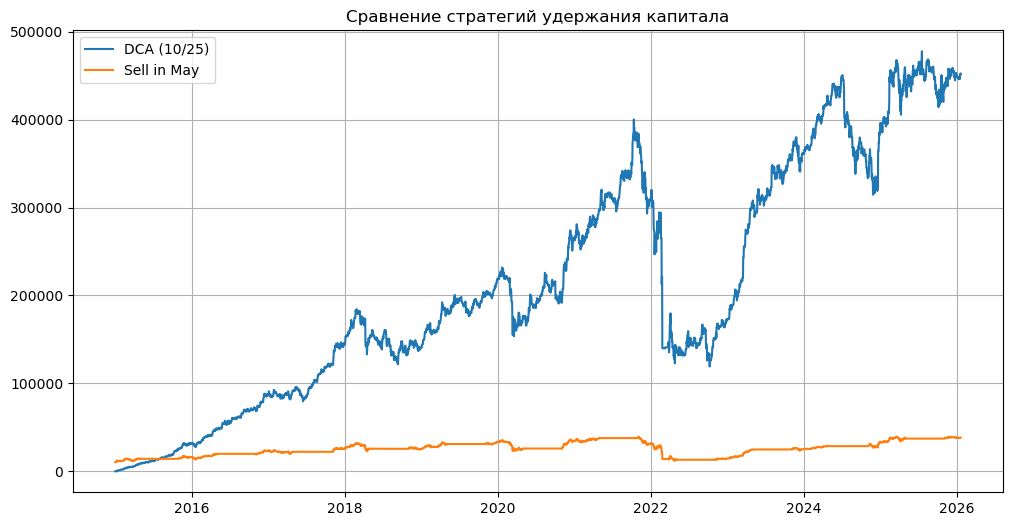

In [136]:
import matplotlib.pyplot as plt

# Получаем данные (пример)
ret_dca, val_dca, hist_dca = benchmark_dca(df_SBER)
ret_sim, val_sim, hist_sim = benchmark_sell_in_may(df_SBER)
# hist_dep — это history_df из предыдущей функции про вклады

plt.figure(figsize=(12, 6))

plt.plot(hist_dca.index, hist_dca['Balance'], label='DCA (10/25)')
plt.plot(hist_sim.index, hist_sim['Balance'], label='Sell in May')
# Если у вкладов индекс по годам, можно использовать .step() или аппроксимацию
# plt.plot(hist_dep['Year_Date'], hist_dep['Balance'], label='Bank Deposit')

plt.title('Сравнение стратегий удержания капитала')
plt.legend()
plt.grid(True)
plt.show()

Стратегия с банковским вкладом

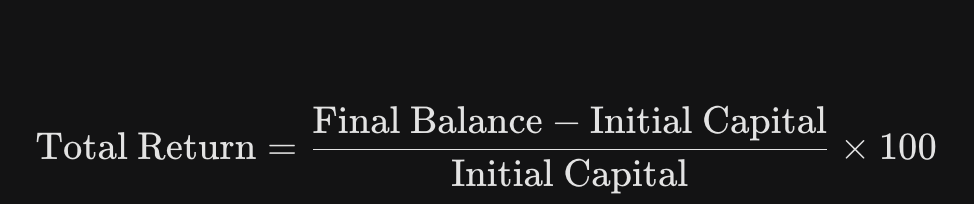

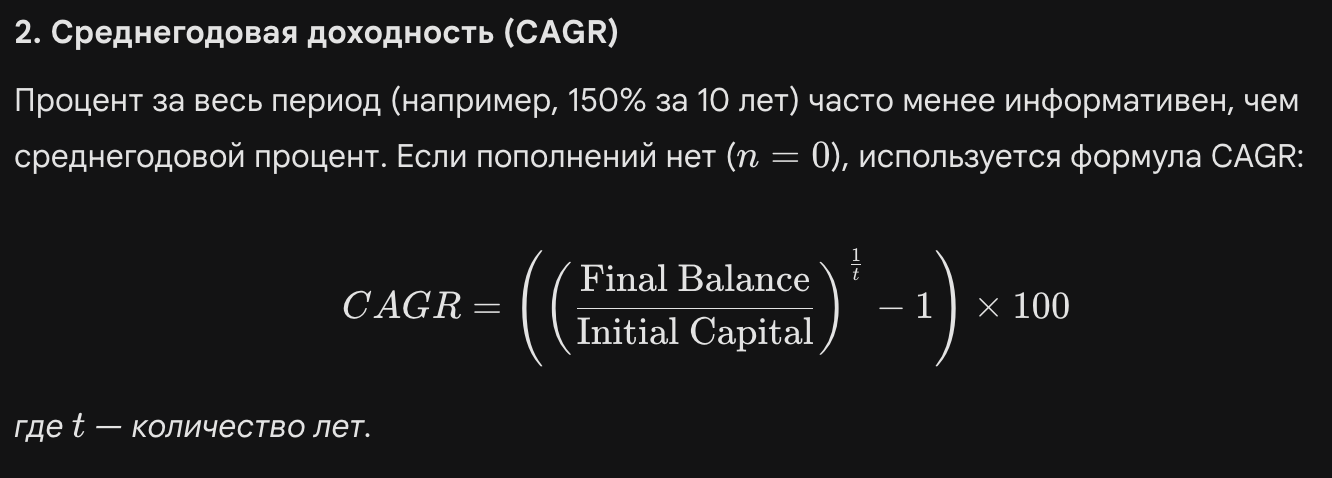

In [207]:
def benchmark_deposit(df_rates: pd.DataFrame, initial_capital: float = 100000, n: float = 0, start_year: int = 2015, end_year: int = 2025) -> tuple[float, float, pd.DataFrame]:
    """
    initial_capital: Стартовая сумма
    n: Сумма ежегодной капитализации, если она есть
    df_rates: DataFrame с колонкой 'BankRate' и годами в индексе
    start_year: Год начала (int)
    end_year: Год окончания (int)
    
    Returns:
        tuple: (чистая_доходность_%, финальный_баланс, df_history)
    """
    current_balance = initial_capital
    total_invested = initial_capital  # Отслеживаем общую сумму внесенных средств
    history = []
    
    # Добавляем стартовую точку (начало первого года)
    history.append({
        'Year': start_year,
        'Balance': current_balance,
        'Rate': 0,
        'Profit': 0,
        'Invested': initial_capital
    })
    
    # Цикл по годам
    for year in range(start_year, end_year + 1):
        if year in df_rates.index:
            rate = df_rates.loc[year, 'BankRate']
            
            # В конце года получаем выплату
            profit = current_balance * rate
            current_balance += profit
            current_balance += n
            total_invested += n # Учитываем ежегодное пополнение в общей сумме вложений
            
            history.append({
                'Year': year + 1, # Состояние на 1 января следующего года
                'Balance': round(current_balance, 2),
                'Rate': rate,
                'Profit': round(profit, 2), 
                'Invested': round(current_balance, 2) - round(profit, 2)
            })
        else:
            print(f"Предупреждение: Ставка за {year} год не найдена.")
            
    # Превращаем историю в DataFrame для удобного построения графиков
    df_history = pd.DataFrame(history)
    
    # ИЗМЕНЕНИЕ: Считаем доходность только от заработанных процентов (Net ROI), 
    # а не просто разницу между началом и концом, чтобы не учитывать пополнения как прибыль.
    net_profit = current_balance - total_invested
    total_return_pct = (net_profit / total_invested) * 100
    
    return total_return_pct, current_balance, df_history

In [212]:
start_cap = 100000 # 100 тысяч рублей
ret_pct, final_val, history_df = benchmark_deposit(df_market, start_cap, 1000, 2015, 2025)

print(f"Итоговая доходность вкладов: {ret_pct:.2f}%")
print(f"Финальная сумма: {final_val:.2f}")

# Посмотрим на историю роста
print(history_df)

Итоговая доходность вкладов: 174.48%
Финальная сумма: 304677.78
    Year    Balance     Rate    Profit   Invested
0   2015  100000.00  0.00000      0.00  100000.00
1   2016  116325.00  0.15325  15325.00  101000.00
2   2017  128945.87  0.09990  11620.87  117325.00
3   2018  140777.32  0.08400  10831.45  129945.87
4   2019  151976.64  0.07245  10199.32  141777.32
5   2020  164418.96  0.07529  11442.32  152976.64
6   2021  175164.07  0.05927   9745.11  165418.96
7   2022  184021.93  0.04486   7857.86  176164.07
8   2023  199261.55  0.07738  14239.62  185021.93
9   2024  216461.51  0.08130  16199.96  200261.55
10  2025  249482.66  0.14793  32021.15  217461.51
11  2026  304677.78  0.21723  54195.12  250482.66


In [213]:
start_cap = 100000 # 100 тысяч рублей
ret_pct, final_val, history_df = benchmark_sell_in_may(prepare_daily_data(df_SBER), start_cap, start_year=2015, end_year=2025)

print(f"Итоговая доходность sell in may: {ret_pct:.2f}%")
print(f"Финальная сумма: {final_val:.2f}")

# Посмотрим на историю роста
print(history_df)

Итоговая доходность sell in may: 24.65%
Финальная сумма: 124654.98
   Year    Balance     Rate    Profit  Invested
0  2018   81711.16 -0.18289 -18288.84    100000
1  2019  108682.54  0.33008  26971.38    100000
2  2020  111832.63  0.02898   3150.09    100000
3  2021  100726.22 -0.09931 -11106.41    100000
4  2022   47452.98 -0.52889 -53273.24    100000
5  2023   81706.94  0.72185  34253.96    100000
6  2024  110592.56  0.35353  28885.62    100000
7  2025  124654.98  0.12716  14062.42    100000


In [214]:
start_cap = 1000 # 100 тысяч рублей
ret_pct, final_val, history_df = benchmark_dca(prepare_daily_data(df_SBER), start_cap, start_year=2015, end_year=2025)

print(f"Итоговая доходность DCA {ret_pct:.2f}%")
print(f"Финальная сумма: {final_val:.2f}")

# Посмотрим на историю роста
print(history_df)

Итоговая доходность DCA 33.89%
Финальная сумма: 251709.18
   Year    Balance     Rate    Profit  Invested
0  2018   18096.32 -1.90368  -1903.68     20000
1  2019   51691.35  0.53022   9595.03     44000
2  2020   84528.56  0.17096   8837.21     68000
3  2021  114376.23  0.06918   5847.67     92000
4  2022   80580.46 -0.50531 -57795.77    116000
5  2023  182362.38  0.96527  77781.92    140000
6  2024  213510.96  0.03920   7148.58    164000
7  2025  251709.18  0.06650  14198.22    188000


In [144]:
df_SBER = get_candles_data("SBER", start_date=datetime(2015, 1, 1))

Подтверждено: SBER (Сбер Банк), FIGI: BBG004730N88
